In [1]:
!date

Tue Feb 24 18:20:03 CET 2026


In [2]:
pwd

'/Users/aidasaglinskas/Desktop/ANDSpeak/Google_drive_things/Code-2026'

In [155]:
import os
import pandas as pd
import numpy as np
from pydub import AudioSegment
from tqdm import tqdm

In [10]:
df = pd.read_csv('../DementiaBank-preprocessed2/file_list.csv')
n = len(df)
df.sample(10)

,Unnamed: 0.1,Unnamed: 0,path,site,group,filename,diag,subName,size_MB,dur_s,dur_m
157,157,21,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Lu,control,F53.mp3,C,Lu_C_F53,0.76,79.29,1.321500
211,211,21,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,control,34-1.mp3,C,Delaware_C_34,4.66,305.46,5.091000
17,17,17,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Pitt,dementia,016-3.mp3,D,Pitt_D_016,0.53,34.79,0.579833
258,258,34,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,dementia,75-1.mp3,D,Delaware_D_75,10.12,663.36,11.056000
275,275,51,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,dementia,50-1.mp3,D,Delaware_D_50,5.04,329.87,5.497833
45,45,45,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Pitt,dementia,066-0.mp3,D,Pitt_D_066,1.24,81.18,1.353000
190,190,0,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,control,04-1.mp3,C,Delaware_C_04,7.36,482.03,8.033833
144,144,8,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Lu,control,F34.mp3,C,Lu_C_F34,0.12,43.60,0.726667
152,152,16,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Lu,control,F55.mp3,C,Lu_C_F55,0.51,55.37,0.922833
55,55,55,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Pitt,dementia,065-2.mp3,D,Pitt_D_065,1.86,121.72,2.028667


In [84]:
# TextFiles
indir = '../DementiaBank-preprocessed2/02-patient-speaker-files/patient-text/'
l = []
for f in range(n):
    fn = df['filename'].values[f].replace('.mp3','.txt')
    filename = os.path.join(indir,fn)
    if os.path.exists(filename):
        with open(filename,'r') as text:
            conts = text.read()
            l.append(len(conts))
    else:
        l.append(0)

df['speaker_text_len'] = l

In [61]:
# TextComplexity
indir = '../DementiaBank-preprocessed2/03-textcomplexity-features/'
l = []
for f in range(len(df)):
    fn = df['filename'].values[f].replace('.mp3','.csv')
    filename = os.path.join(indir,fn)
    l.append( os.path.exists(filename) )
df['has_complexity_f'] = l

In [130]:
# Disvoice
indir = '../DementiaBank-preprocessed2/05-speech-features-merged/'
l = []
for f in range(len(df)):
    fn = df['filename'].values[f].replace('.mp3','.csv')
    filename = os.path.join(indir,fn)
    l.append( os.path.exists(filename) )
df['has_disvoice_f'] = l

In [186]:
# Audio files and lengths
indir = '../DementiaBank-preprocessed2/02-patient-speaker-files/patient-audio/'
num_files = []
len_sum = []
for f in tqdm(range(len(df))):
    fn = df['filename'].values[f].replace('.mp3','')
    subdir = os.path.join(indir,fn)
    if os.path.exists(subdir):
        files = [f for f in os.listdir(subdir) if f.endswith('.mp3')]
        num_files.append(len(files))
        if len(files)>0:
            l = 0
            for file in files:
                try:
                    audio = AudioSegment.from_file(os.path.join(subdir,file))
                    audio_l = len(audio)/1000
                    l+=audio_l
                except:
                    pass
            len_sum.append(l)
        else:
            len_sum.append(0)
    else:
        num_files.append(0)
        len_sum.append(0)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 285/285 [08:46<00:00,  1.85s/it]


In [184]:
#len_sum = np.array(len_sum).round(2).round(2)

In [187]:
df['num_audio_files'] = num_files
df['sum_audio_len'] = len_sum

In [188]:
df

,Unnamed: 0.1,Unnamed: 0,path,site,group,filename,diag,subName,size_MB,dur_s,dur_m,speaker_text_len,has_complexity_f,has_disvoice_f,num_audio_files,sum_audio_len
0,0,0,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Pitt,dementia,033-1.mp3,D,Pitt_D_033,2.38,155.83,2.597167,635,True,True,4,52.000
1,1,1,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Pitt,dementia,033-0.mp3,D,Pitt_D_033,0.85,55.58,0.926333,631,True,True,4,51.950
2,2,2,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Pitt,dementia,076-0.mp3,D,Pitt_D_076,1.25,81.83,1.363833,865,True,True,9,54.350
3,3,3,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Pitt,dementia,049-0.mp3,D,Pitt_D_049,1.07,70.18,1.169667,548,True,True,7,34.852
4,4,4,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Pitt,dementia,076-2.mp3,D,Pitt_D_076,1.45,95.13,1.585500,1310,True,True,10,83.099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,280,56,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,dementia,33-1.mp3,D,Delaware_D_33,6.50,425.59,7.093167,4140,True,True,38,331.800
281,281,57,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,dementia,15-2.mp3,D,Delaware_D_15,8.86,857.43,14.290500,4809,True,True,72,443.054
282,282,58,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,dementia,69-1.mp3,D,Delaware_D_69,4.25,278.69,4.644833,1328,True,True,11,112.048
283,283,59,/Users/aidasaglinskas/Desktop/ANDSpeak/Google_...,Delaware,dementia,11-1.mp3,D,Delaware_D_11,15.24,998.52,16.642000,9000,True,True,98,706.602


In [190]:
df['has_complexity_f'].values.sum()

213

In [191]:
df['has_disvoice_f'].values.sum()

248

In [199]:
from matplotlib import pyplot as plt
import seaborn as sns

/var/folders/pb/w12g8_yx1b9d3k2rxmhxqjc40000gn/T/ipykernel_66574/3473454975.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['speaker_text_len'].values[df['speaker_text_len'].values>0])


<Axes: ylabel='Density'>

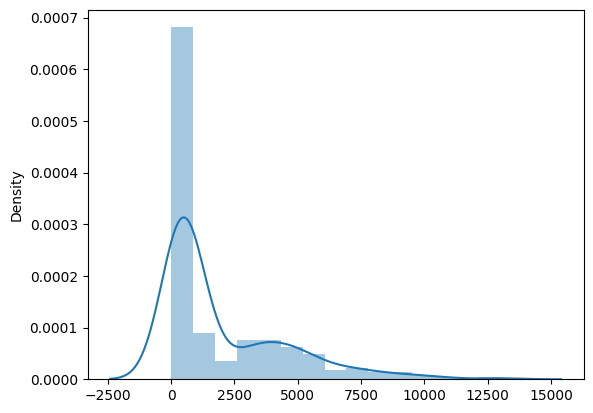

In [202]:
sns.distplot(df['speaker_text_len'].values[df['speaker_text_len'].values>0])

(array([163.,  16.,  34.,  11.,  12.,   4.,   3.,   4.,   1.,   1.]),
 array([  1. ,  15.4,  29.8,  44.2,  58.6,  73. ,  87.4, 101.8, 116.2,
        130.6, 145. ]),
 <BarContainer object of 10 artists>)

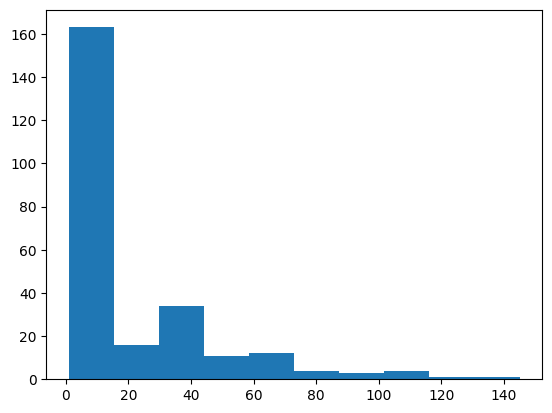

In [205]:
plt.hist(df['num_audio_files'].values[df['num_audio_files'].values>0])

In [206]:
df.to_csv('../DementiaBank-preprocessed2/file_list_annot_v2.csv')